In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
work_df = pd.read_csv('data/pat_work_df.csv')
work_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID истории болезни  242 non-null    object 
 1   gender              242 non-null    int64  
 2   age                 242 non-null    int64  
 3   rbc                 242 non-null    float64
 4   hgb                 242 non-null    float64
 5   hct                 242 non-null    float64
 6   mcv                 242 non-null    float64
 7   mch                 242 non-null    float64
 8   mchc                242 non-null    float64
 9   rdw                 241 non-null    float64
 10  rdv_cv              136 non-null    float64
 11  rdv_sd              139 non-null    float64
 12  ret_rel             37 non-null     float64
 13  ret_abs             29 non-null     float64
 14  cp                  241 non-null    float64
 15  anisocytos          34 non-null     float64
 16  hypochro

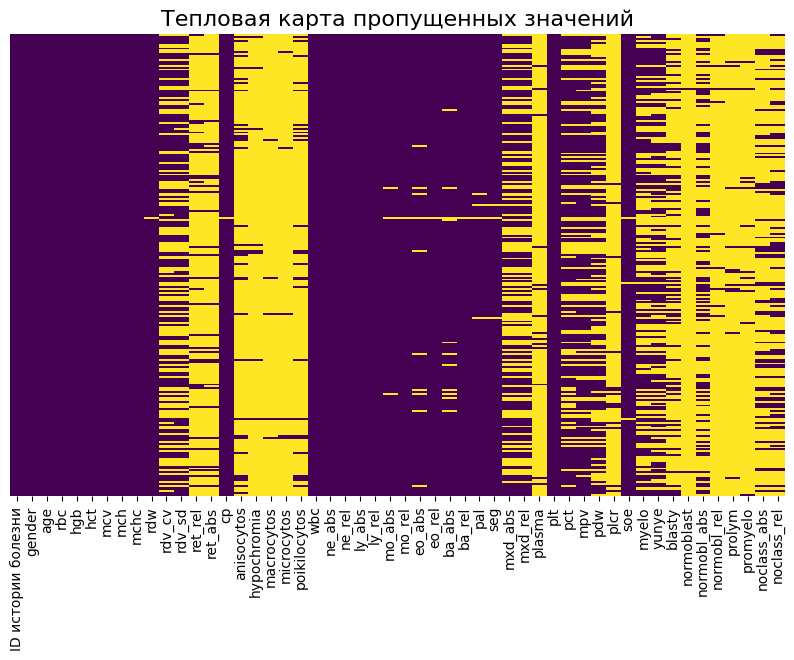

In [3]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [4]:
def rel_tocol_calc(rel_col, abs_col):
    # Условия: есть rel, есть WBC, нет abs
    cond_rel_to_abs = (
        work_df[rel_col].notna() &
        work_df['wbc'].notna() &
        work_df[abs_col].isna()
    )

    work_df.loc[cond_rel_to_abs, abs_col] = (
        work_df.loc[cond_rel_to_abs, rel_col] * work_df.loc[cond_rel_to_abs, 'wbc'] * 0.01
    )

    cond_rel_to_wbc = (
        work_df[rel_col].notna() &
        work_df['wbc'].isna() &
        work_df[abs_col].notna()    
    )

    work_df.loc[cond_rel_to_wbc, 'wbc'] = (
        work_df.loc[cond_rel_to_wbc, abs_col] / work_df.loc[cond_rel_to_wbc, rel_col] * 100
    )

In [5]:
# Пары: (абсолютное, относительное)
leukocyte_pairs = [
    ('ne_abs', 'ne_rel'),
    ('ly_abs', 'ly_rel'),
    ('mo_abs', 'mo_rel'),
    ('eo_abs', 'eo_rel'),
    ('ba_abs', 'ba_rel'),
    ('mxd_abs', 'mxd_rel'),
    ('ret_abs', 'ret_rel'),
    ('noclass_abs', 'noclass_rel'),
]

# Перебор всех пар
for abs_col, rel_col in leukocyte_pairs:
    rel_tocol_calc(abs_col, rel_col)


HCT (%) = RBC (кол-во эритроцитов, ×10¹²/л) × MCV (средний объем эритроцита, фл) × 0.1

In [6]:
# Расчитаем значения по эритроцитам через Hct и MCV
cond_hct = (
    work_df['hct'].isna() &
    work_df['rbc'].notna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_hct, 'hct'] = (
    work_df.loc[cond_hct, 'rbc'] * work_df.loc[cond_hct, 'mcv'] * 0.1
)

cond_rbc = (
    work_df['hct'].notna() &
    work_df['rbc'].isna() &
    work_df['mcv'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hct'] * 10 / work_df.loc[cond_rbc, 'mcv']
)

cond_mcv = (
    work_df['hct'].notna() &
    work_df['rbc'].notna() &
    work_df['mcv'].isna()
)

work_df.loc[cond_mcv, 'mcv'] = (
    work_df.loc[cond_mcv, 'hct'] * 10 / work_df.loc[cond_mcv, 'rbc']
)

In [7]:
# Расчитаем значения по эритроцитам через hgb и MCH
cond_hgb = (
    work_df['hgb'].isna() &
    work_df['rbc'].notna() &
    work_df['mch'].notna()
)

work_df.loc[cond_hgb, 'hgb'] = (
    work_df.loc[cond_hgb, 'rbc'] * work_df.loc[cond_hgb, 'mch'] * 0.1
)

cond_rbc = (
    work_df['hgb'].notna() &
    work_df['rbc'].isna() &
    work_df['mch'].notna()
)

work_df.loc[cond_rbc, 'rbc'] = (
    work_df.loc[cond_rbc, 'hgb'] * 10 / work_df.loc[cond_rbc, 'mch']
)

cond_mch = (
    work_df['hgb'].notna() &
    work_df['rbc'].notna() &
    work_df['mch'].isna()
)

work_df.loc[cond_mch, 'mch'] = (
    work_df.loc[cond_mch, 'hgb'] * 10 / work_df.loc[cond_mch, 'rbc']
)

In [8]:
# Расчитаем значения по тромбоцитам где можно
cond_pct = (
    work_df['pct'].isna() &
    work_df['plt'].notna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_pct, 'pct'] = (
    work_df.loc[cond_pct, 'plt'] * work_df.loc[cond_pct, 'mpv'] * 0.1
)

cond_plt = (
    work_df['pct'].notna() &
    work_df['plt'].isna() &
    work_df['mpv'].notna()
)

work_df.loc[cond_plt, 'plt'] = (
    work_df.loc[cond_plt, 'pct'] * 10 / work_df.loc[cond_plt, 'mpv']
)

cond_mpv = (
    work_df['pct'].notna() &
    work_df['plt'].notna() &
    work_df['mpv'].isna()
)

work_df.loc[cond_mpv, 'mpv'] = (
    work_df.loc[cond_mpv, 'pct'] * 10 / work_df.loc[cond_mpv, 'plt']
)

In [9]:
list_to_drop = [
    'ne_rel', 'ly_rel', 'mo_rel', 'ret_rel',
    'eo_rel', 'ba_rel', 'mxd_rel', 'normobl_rel',
    'pct', 'mch', 'rdv_cv',
    'noclass_abs', 'noclass_rel',

]
work_df = work_df.drop(columns=list_to_drop)

In [10]:
norm_null_list = ['plasma', 'myelo', 'yunye', 'blasty', 'normobl_abs',
                  'prolym', 'promyelo', 'normoblast',
                  'plcr', 'hypochromia',
                  'macrocytos', 'microcytos',
                  'anisocytos', 'poikilocytos',
                  ]
# Заменим пустые значения но 0 (норма там где можно)
work_df[norm_null_list] = work_df[norm_null_list].fillna(0)

In [11]:
work_df = work_df.dropna(subset=['rbc', 'wbc'], how='all')
work_df.shape

(242, 39)

In [12]:
leu_formula_list = ['ne_abs', 'ly_abs', 'mo_abs',
                    'eo_abs', 'ba_abs', 
                    'pal', 'seg', 'mxd_abs', 'plasma', # в норме - 0-1%
                    ]

leuf_df = work_df[leu_formula_list]

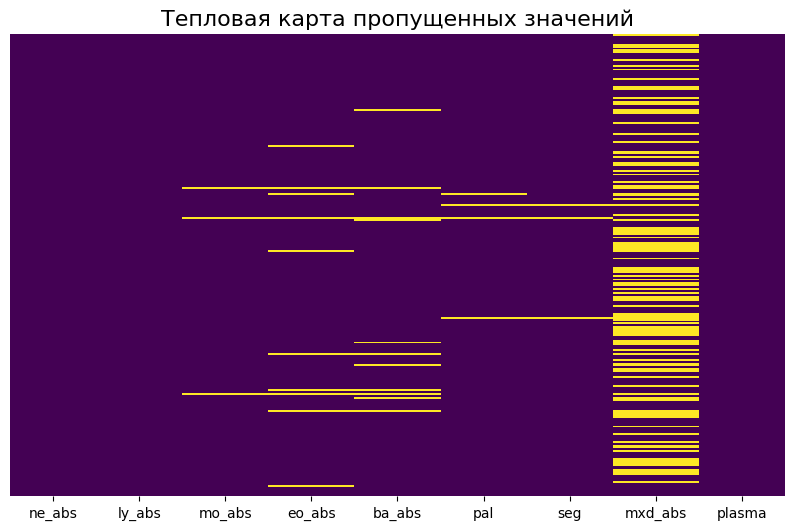

In [13]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(leuf_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [15]:
# cat_list = ['study_ID', 'gender', 'plasma', 'myelo', 'yunye', 'blasty',
cat_list = ['ID истории болезни', 'gender', 'plasma', 'myelo', 'yunye', 'blasty',
            'prolym', 'promyelo', 'normoblast', 'hypochromia',
            'macrocytos', 'microcytos', 'anisocytos', 'poikilocytos',]
num_list = [col for col in work_df.columns if col not in cat_list]
work_df[cat_list] = work_df[cat_list].astype('object')

In [16]:
ref_dict = { # Словарь референсных значений
    'rbc': [3.8, 5.8],
    'hgb': [120, 140],
    'hct': [39, 49],
    'mcv': [81, 100],
    'mchc': [320, 360],
    'rdw': [11.5, 14.5],
    'rdv_sd': [37, 54],
    'ret_abs': [0.67, 1.9],
    'cp': [0.85, 1],
    'wbc': [4, 9],
    'ne_abs': [2, 5.5],
    'ly_abs': [1, 4.8],
    'mo_abs': [0.04, 0.7],
    'eo_abs': [0.02, 0.45],
    'ba_abs': [0.01, 0.05],
    'pal': [1, 5],
    'seg': [47, 72],
    'mxd_abs': [0.2, 0.8],
    'plt': [180, 320],
    'mpv': [7.4, 10.4],
    'pdw': [15, 17],
    'plcr': [13, 43],
    'soe': [2, 10],
    'ret_abs': [17, 63],
}

In [17]:
import numpy as np
np.random.seed(42)

for col in ref_dict:
    mask = work_df[col].isna()
    work_df.loc[mask, col] = np.random.uniform(ref_dict[col][0], ref_dict[col][1], size=mask.sum())

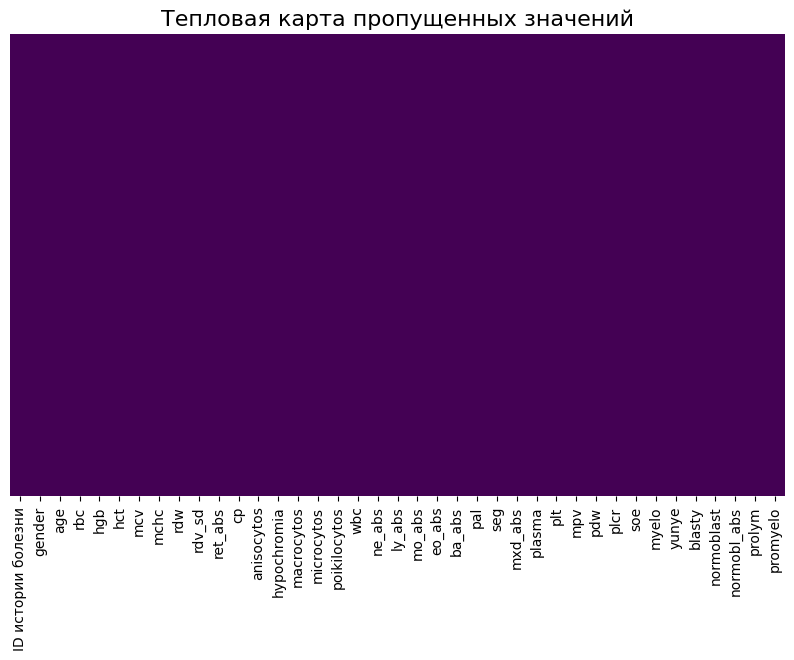

In [18]:
# Создаем тепловую карту пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(work_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Тепловая карта пропущенных значений', fontsize=16)
plt.show()

In [19]:
# work_df[work_df.isnull().sum(axis=1) < 10].describe().T
work_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,242.0,69.681818,12.863874,10.000000,62.000000,71.000000,77.000000,90.000000
rbc,242.0,4.121540,1.415392,1.400000,3.200536,3.656667,4.860000,9.397500
hgb,242.0,114.800351,30.106544,50.400000,92.333333,105.785714,137.916667,190.666667
hct,242.0,35.070688,10.419262,14.066667,26.881250,31.633333,42.991667,64.366667
mcv,242.0,86.581572,10.097587,62.414286,80.469613,84.882051,91.583333,124.200000
mchc,242.0,320.436431,46.286826,82.983333,316.270833,332.000000,342.127976,375.500000
rdw,242.0,18.016007,3.730276,11.250000,15.333333,17.591667,20.157500,32.050000
rdv_sd,242.0,49.528721,8.483645,37.093876,43.451878,49.008287,52.992871,97.600000
ret_abs,242.0,44.309508,23.111349,6.800000,28.741329,41.915434,54.510470,186.600000
cp,242.0,0.861210,0.116612,0.490000,0.816167,0.860000,0.907292,1.295000


In [20]:
work_df.describe(include='object').T

,count,unique,top,freq
ID истории болезни,242,242,05deb1af-cf40-11e9-80ba-901b0e633689,1
gender,242,2,0,122
anisocytos,242.0,2.0,0.0,208.0
hypochromia,242.0,2.0,0.0,234.0
macrocytos,242.0,2.0,0.0,238.0
microcytos,242.0,2.0,0.0,237.0
poikilocytos,242.0,2.0,0.0,217.0
plasma,242.0,6.0,0.0,233.0
myelo,242.0,49.0,0.0,115.0
yunye,242.0,40.0,0.0,117.0


In [21]:
etalon_df = work_df.copy()

In [22]:
etalon_df.to_csv('data/pat_etalon_df.csv', index=False)